# Exploratory Data Analysis - Monash Energy Time Series

**Standalone EDA** for the thesis *"Foundation Models for Zero-Shot Energy Forecasting"*.
This notebook characterises the energy data used in the study - **electricity demand (load),
solar generation, and wind generation** from the Monash Time Series Forecasting Archive -
before any modelling. It covers data overview, quality checks, value distributions, and
(most important for forecasting) **daily / weekly / yearly seasonality**.


## 1. Setup

In [1]:
%pip install -q "datasets>=2.19" pandas pyarrow matplotlib numpy 2>/dev/null
%pip install -q numpy
print("Dependencies ready.")


Note: you may need to restart the kernel to use updated packages.


The system cannot find the path specified.


Note: you may need to restart the kernel to use updated packages.
Dependencies ready.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Configuration

One Monash dataset per energy type (each at its native resolution). `SERIES_PER_TYPE`
controls how many series are profiled — raise it for a fuller description, lower it if
memory is tight (wind is minutely and long).


In [2]:
import numpy as np
np.random.seed(7)

BASE = {
    "load":  {"config": "australian_electricity_demand", "native_freq": "30min", "label": "AU Electricity Demand"},
    "solar": {"config": "solar_10_minutes",              "native_freq": "10min", "label": "Solar Generation"},
    "wind":  {"config": "wind_farms_minutely",           "native_freq": "1min",  "label": "Wind Generation"},
}
NATIVE_M = {"load": 48, "solar": 144, "wind": 1440}   # steps per day at native resolution

SERIES_PER_TYPE = 5      # how many series per type to profile
RANDOM_SEED     = 7
print("Types:", list(BASE), "| series per type:", SERIES_PER_TYPE)


Types: ['load', 'solar', 'wind'] | series per type: 5


## 3. Load the Monash energy datasets

In [3]:
from datasets import load_dataset
import pandas as pd

def load_monash(config):
    ds = load_dataset("Monash-University/monash_tsf", config, trust_remote_code=True)
    split = "test" if "test" in ds else list(ds.keys())[0]
    out = []
    for row in ds[split]:
        arr = np.asarray(row["target"], float); arr = arr[np.isfinite(arr)]
        if arr.size: out.append({"target": arr, "start": row.get("start", None)})
    return out

def to_series(entry, freq):
    try:
        idx = pd.date_range(pd.Timestamp(entry["start"]), periods=len(entry["target"]), freq=freq)
    except Exception:
        idx = pd.date_range("2015-01-01", periods=len(entry["target"]), freq=freq)
    return pd.Series(entry["target"], index=idx)

DATA = {}
for et, info in BASE.items():
    print(f"Loading {info['config']} ({et}) ...", end=" ", flush=True)
    raw = load_monash(info["config"])
    rng = np.random.default_rng(RANDOM_SEED)
    pick = [raw[i] for i in rng.permutation(len(raw))[:SERIES_PER_TYPE]]
    DATA[et] = [to_series(e, info["native_freq"]) for e in pick]
    print(f"{len(raw)} series available -> profiling {len(DATA[et])}")


e:\Thesis\EnergyForcastModel\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading australian_electricity_demand (load) ... 5 series available -> profiling 5
Loading solar_10_minutes (solar) ... 137 series available -> profiling 5
Loading wind_farms_minutely (wind) ... 339 series available -> profiling 5


## 4. Data overview - feature table & summary
Frequency, length, time span and value statistics per series, plus a per-type summary.
`pct_zeros` = share of exact-zero readings (≈0 for demand, high for solar at night).

In [4]:
import pandas as pd
rows = []
for et, series_list in DATA.items():
    info = BASE[et]
    for sid, s in enumerate(series_list):
        v = s.values.astype(float)
        rows.append({
            "type": et, "dataset": info["config"], "native_freq": info["native_freq"],
            "series_id": sid, "n_points": len(v),
            "start": str(s.index[0].date()), "end": str(s.index[-1].date()),
            "span_days": round((s.index[-1]-s.index[0]).total_seconds()/86400, 1),
            "mean": round(float(v.mean()),2), "std": round(float(v.std()),2),
            "min": round(float(v.min()),2), "max": round(float(v.max()),2),
            "median": round(float(np.median(v)),2),
            "pct_zeros": round(100*float((v==0).mean()),1),
            "seasonal_period_steps_per_day": NATIVE_M[et],
        })
features = pd.DataFrame(rows)
print("Per-series feature table:"); display(features)

summary = (features.groupby("type")
           .agg(dataset=("dataset","first"), native_freq=("native_freq","first"),
                n_series=("series_id","count"), min_points=("n_points","min"),
                max_points=("n_points","max"), mean_value=("mean","mean"),
                avg_pct_zeros=("pct_zeros","mean")).round(1))
print("\\nPer-type summary:"); display(summary)
features.to_csv("eda_dataset_features.csv", index=False)
print("\\nSaved eda_dataset_features.csv")


Per-series feature table:


,type,dataset,native_freq,series_id,n_points,start,end,span_days,mean,std,min,max,median,pct_zeros,seasonal_period_steps_per_day
0,load,australian_electricity_demand,30min,0,232272,2002-01-01,2015-04-01,4839.0,4319.36,876.44,2008.62,7514.44,4371.15,0.0,48
1,load,australian_electricity_demand,30min,1,230736,2002-01-01,2015-02-28,4807.0,6740.52,1361.92,3498.39,12865.80,6783.57,0.0,48
2,load,australian_electricity_demand,30min,2,230736,2002-01-01,2015-02-28,4807.0,507.20,147.32,-233.91,1093.50,489.64,0.0,48
3,load,australian_electricity_demand,30min,3,230736,2002-01-01,2015-02-28,4807.0,4638.96,836.37,2688.52,9494.01,4573.12,0.0,48
4,load,australian_electricity_demand,30min,4,230784,2002-01-01,2015-03-01,4808.0,1290.59,301.12,488.84,3182.48,1271.58,0.0,48
5,solar,solar_10_minutes,10min,0,52560,2006-01-01,2006-12-31,365.0,8.06,11.84,0.00,44.05,0.00,55.0,144
6,solar,solar_10_minutes,10min,1,52560,2006-01-01,2006-12-31,365.0,5.45,7.96,0.00,30.10,0.00,55.3,144
7,solar,solar_10_minutes,10min,2,52560,2006-01-01,2006-12-31,365.0,5.68,8.45,0.00,33.35,0.00,55.2,144
8,solar,solar_10_minutes,10min,3,52560,2006-01-01,2006-12-31,365.0,5.31,7.85,0.00,29.40,0.00,55.3,144
9,solar,solar_10_minutes,10min,4,52560,2006-01-01,2006-12-31,365.0,4.28,6.31,0.00,24.35,0.00,55.6,144


\nPer-type summary:


,dataset,native_freq,n_series,min_points,max_points,mean_value,avg_pct_zeros
type,,,,,,,
load,australian_electricity_demand,30min,5,230736,232272,3499.3,0.0
solar,solar_10_minutes,10min,5,52560,52560,5.8,55.3
wind,wind_farms_minutely,1min,5,434876,434876,73.8,42.4


\nSaved eda_dataset_features.csv


## 5. Statistical description (pandas .describe) per type

In [5]:
for et, series_list in DATA.items():
    allv = np.concatenate([s.values.astype(float) for s in series_list])
    print(f"\\n=== {BASE[et]['label']} ({et}, {BASE[et]['native_freq']}) — "
          f"{len(series_list)} series, {len(allv)} points ===")
    display(pd.Series(allv).describe().round(2).to_frame(name=et))


\n=== AU Electricity Demand (load, 30min) — 5 series, 1155264 points ===


,load
count,1155264.00
mean,3500.32
std,2437.73
min,-233.91
25%,1065.01
50%,3836.73
75%,5215.72
max,12865.80


\n=== Solar Generation (solar, 10min) — 5 series, 262800 points ===


,solar
count,262800.00
mean,5.75
std,8.77
min,0.00
25%,0.00
50%,0.00
75%,10.25
max,44.05


\n=== Wind Generation (wind, 1min) — 5 series, 2174380 points ===


,wind
count,2174380.00
mean,73.80
std,124.78
min,0.00
25%,0.00
50%,0.10
75%,82.90
max,449.40


## 6. Head preview & data-quality checks
First rows (timestamp → value) and checks for missing values, duplicate timestamps,
negatives, and constant series.

In [6]:
for et, series_list in DATA.items():
    print(f"\\n=== {BASE[et]['label']} ({et}) — first 5 rows of series 0 ===")
    display(series_list[0].head(5).to_frame(name="value"))


\n=== AU Electricity Demand (load) — first 5 rows of series 0 ===


,value
2002-01-01 00:00:00,3382.041260
2002-01-01 00:30:00,3288.315674
2002-01-01 01:00:00,3172.329102
2002-01-01 01:30:00,3020.312988
2002-01-01 02:00:00,2918.082764


\n=== Solar Generation (solar) — first 5 rows of series 0 ===


,value
2006-01-01 00:00:01,0.0
2006-01-01 00:10:01,0.0
2006-01-01 00:20:01,0.0
2006-01-01 00:30:01,0.0
2006-01-01 00:40:01,0.0


\n=== Wind Generation (wind) — first 5 rows of series 0 ===


,value
2019-08-01 00:00:01,396.500000
2019-08-01 00:01:01,400.000000
2019-08-01 00:02:01,405.600006
2019-08-01 00:03:01,410.200012
2019-08-01 00:04:01,412.799988


In [10]:
# midday rows of the first solar series in mid night value will be 0
display(DATA["solar"][0].between_time("11:00", "13:00").head(10).to_frame("value"))

,value
2006-01-01 11:00:01,13.65
2006-01-01 11:10:01,12.30
2006-01-01 11:20:01,14.15
2006-01-01 11:30:01,12.65
2006-01-01 11:40:01,10.35
2006-01-01 11:50:01,7.00
2006-01-01 12:00:01,6.55
2006-01-01 12:10:01,5.95
2006-01-01 12:20:01,2.55
2006-01-01 12:30:01,3.50


In [7]:
qrows = []
for et, series_list in DATA.items():
    for sid, s in enumerate(series_list):
        v = s.values.astype(float)
        qrows.append({"type": et, "series_id": sid, "n_points": len(v),
                      "n_missing": int(np.isnan(v).sum()),
                      "dup_timestamps": int(s.index.duplicated().sum()),
                      "n_negative": int((v < 0).sum()), "n_zeros": int((v == 0).sum()),
                      "is_constant": bool(np.nanstd(v) < 1e-9)})
quality = pd.DataFrame(qrows); display(quality)
print("Missing total:", int(quality["n_missing"].sum()),
      "| Negative total:", int(quality["n_negative"].sum()),
      "| Any constant series:", bool(quality["is_constant"].any()))


,type,series_id,n_points,n_missing,dup_timestamps,n_negative,n_zeros,is_constant
0,load,0,232272,0,0,0,0,False
1,load,1,230736,0,0,0,0,False
2,load,2,230736,0,0,22,0,False
3,load,3,230736,0,0,0,0,False
4,load,4,230784,0,0,0,0,False
5,solar,0,52560,0,0,0,28894,False
6,solar,1,52560,0,0,0,29060,False
7,solar,2,52560,0,0,0,29039,False
8,solar,3,52560,0,0,0,29091,False
9,solar,4,52560,0,0,0,29211,False


Missing total: 0 | Negative total: 22 | Any constant series: False


## 7. What the series look like (time plots)
One representative series per type (tail shown so short-term structure is visible).

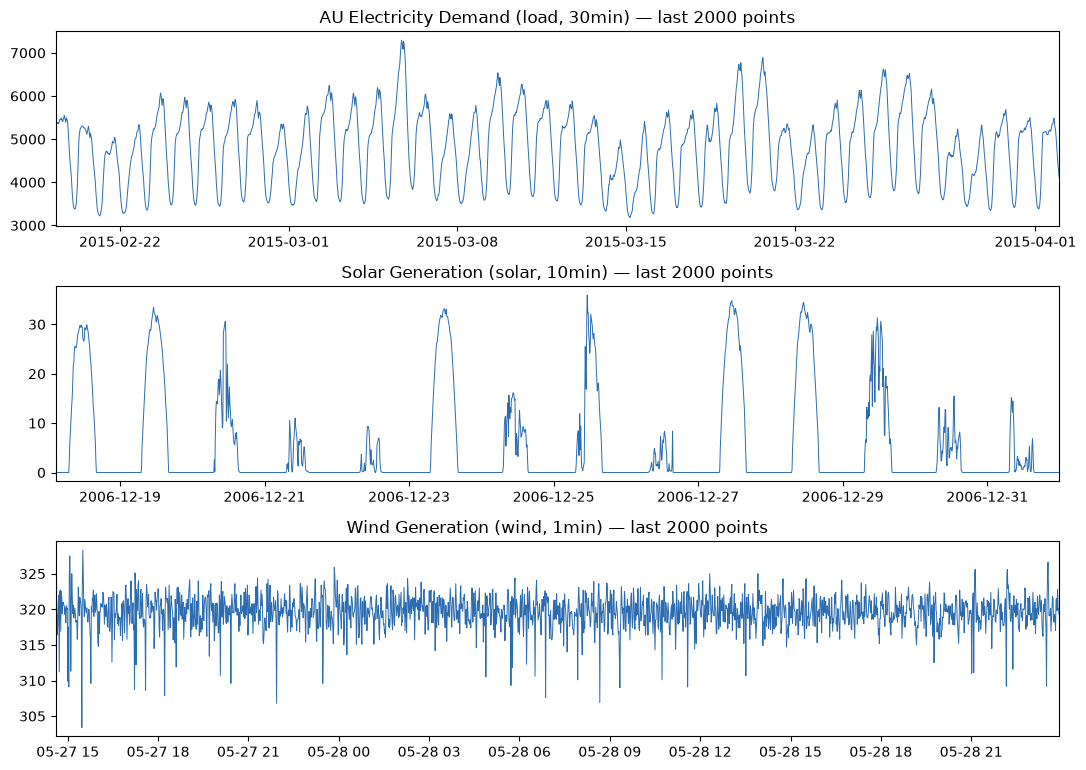

In [8]:
import matplotlib.pyplot as plt
types = list(DATA.keys())
fig, axes = plt.subplots(len(types), 1, figsize=(11, 2.6*len(types)), squeeze=False)
for ax, et in zip(axes[:,0], types):
    s = DATA[et][0]; show = s.iloc[-min(2000, len(s)):]
    ax.plot(show.index, show.values, lw=0.7, color="#2b6cb0")
    ax.set_title(f"{BASE[et]['label']} ({et}, {BASE[et]['native_freq']}) — last {len(show)} points")
    ax.margins(x=0)
plt.tight_layout(); plt.show()


## 8. Value distributions
Histogram per type - demand roughly bell-shaped, solar zero-inflated, wind right-skewed.

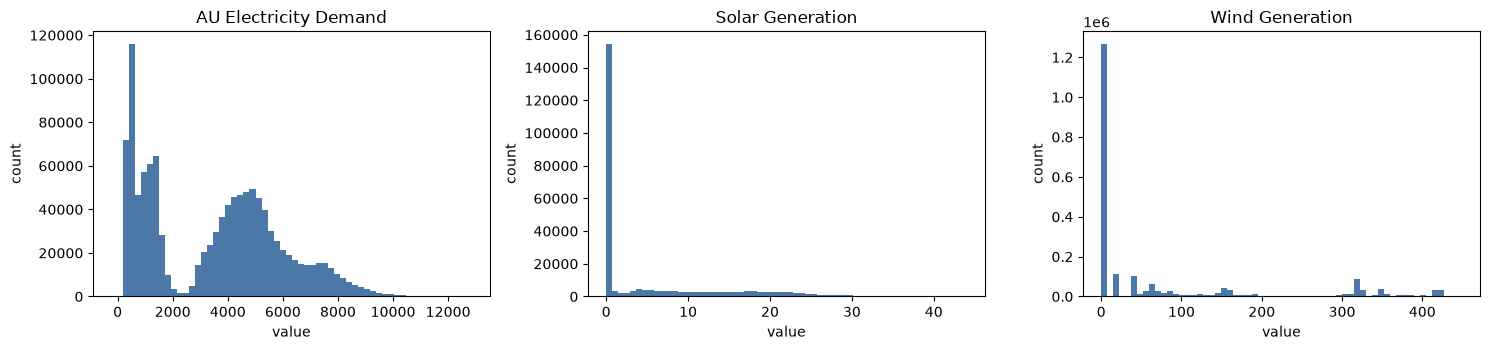

In [9]:
fig, axes = plt.subplots(1, len(types), figsize=(5*len(types), 3.6), squeeze=False)
for ax, et in zip(axes[0], types):
    allv = np.concatenate([s.values.astype(float) for s in DATA[et]])
    ax.hist(allv, bins=60, color="#4c78a8")
    ax.set_title(BASE[et]["label"]); ax.set_xlabel("value"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()


## 9. Daily seasonality - average by hour of day
The key short-term pattern: demand shows morning/evening peaks, solar a midday bell
(zero at night), wind a weak/flat profile.

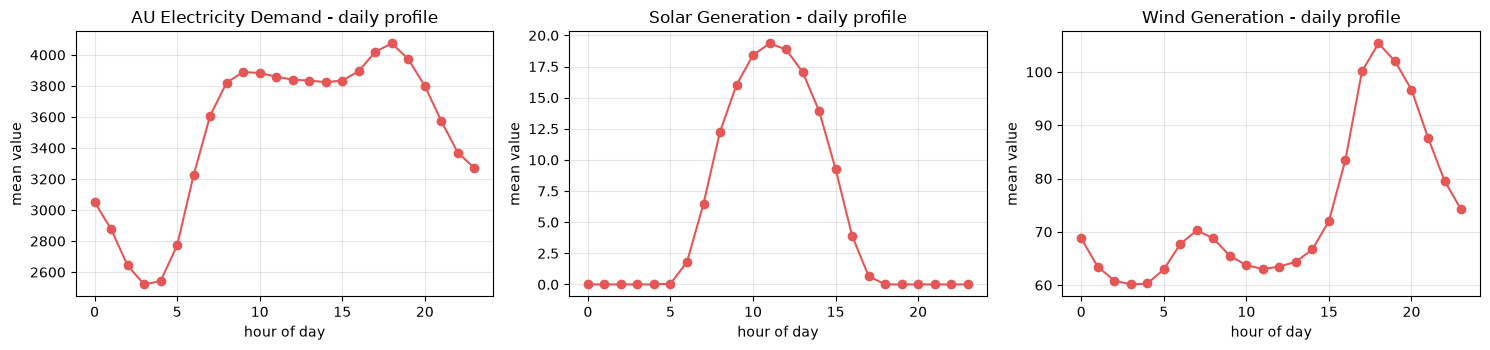

In [15]:
fig, axes = plt.subplots(1, len(types), figsize=(5*len(types), 3.6), squeeze=False)
for ax, et in zip(axes[0], types):
    allc = pd.concat([pd.Series(s.values, index=s.index) for s in DATA[et]])
    prof = allc.groupby(allc.index.hour).mean()
    ax.plot(prof.index, prof.values, marker="o", color="#e45756")
    ax.set_title(f"{BASE[et]['label']} - daily profile")
    ax.set_xlabel("hour of day"); ax.set_ylabel("mean value"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()


## 10. Weekly seasonality - average by day of week
Weekday vs weekend (0 = Mon … 6 = Sun). Demand often dips at weekends; renewables usually
show little weekly structure.

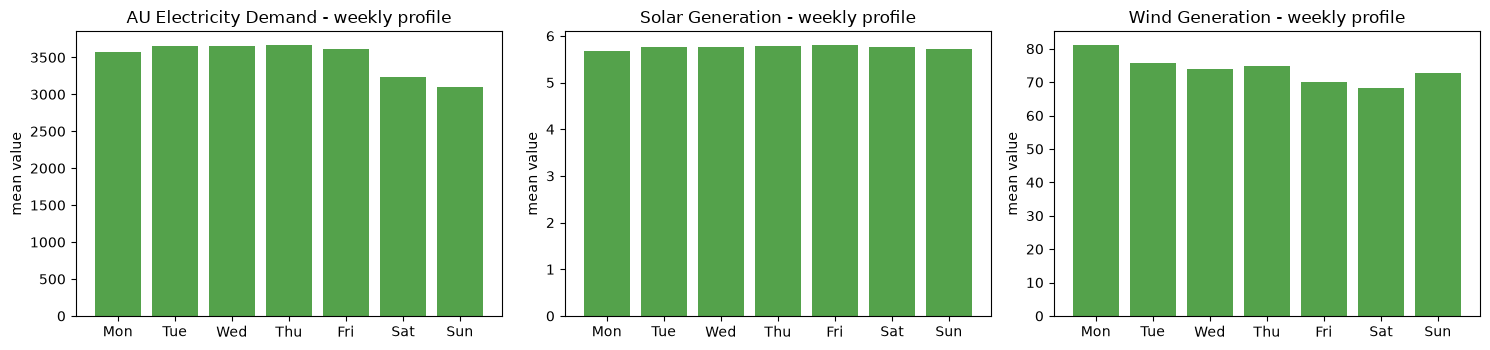

In [14]:
dow = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
fig, axes = plt.subplots(1, len(types), figsize=(5*len(types), 3.6), squeeze=False)
for ax, et in zip(axes[0], types):
    allc = pd.concat([pd.Series(s.values, index=s.index) for s in DATA[et]])
    prof = allc.groupby(allc.index.dayofweek).mean().reindex(range(7))
    ax.bar(range(7), prof.values, color="#54a24b")
    ax.set_xticks(range(7)); ax.set_xticklabels(dow)
    ax.set_title(f"{BASE[et]['label']} - weekly profile"); ax.set_ylabel("mean value")
plt.tight_layout(); plt.show()


## 11. Yearly seasonality - average by month
Seasonal effects across the year (1 = Jan … 12 = Dec), where the series span enough time.

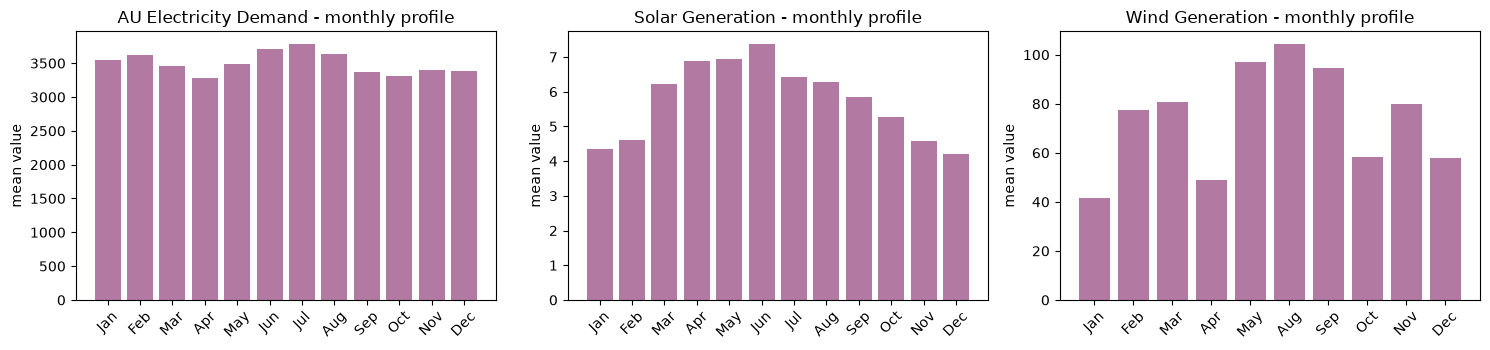

In [16]:
mon = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, axes = plt.subplots(1, len(types), figsize=(5*len(types), 3.6), squeeze=False)
for ax, et in zip(axes[0], types):
    allc = pd.concat([pd.Series(s.values, index=s.index) for s in DATA[et]])
    prof = allc.groupby(allc.index.month).mean()
    ax.bar([mon[m-1] for m in prof.index], prof.values, color="#b279a2")
    ax.set_title(f"{BASE[et]['label']} - monthly profile"); ax.set_ylabel("mean value")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()


## 12. EDA takeaways (fill in from your run)

Summarise what the figures show for **your** sampled series, e.g.:

- **Demand (load):** strong regular daily cycle (morning/evening peaks) + weekday/weekend
  effect → highly structured, should be predictable.
- **Solar:** dominated by day/night on-off (large `pct_zeros`), midday peak, summer
  seasonality → predictable shape but zero-inflation stresses percentage metrics (sMAPE).
- **Wind:** weak daily/weekly structure, right-skewed and volatile → hardest to forecast.

These observations motivate **RQ2** (demand vs. renewables behave differently) and will
explain the later forecasting results. No modelling or train/test split is done here.

**Outputs:** `eda_dataset_features.csv` (data-description table for the appendix).
